## Snippet 1- Percentile rank using relay race results
This snippet introduces percentile rank using real race data. It loads relay results, finds a specific runner’s speed, and computes how that performance compares to others overall and within a division.

In [1]:
# Data Loading

"""
Context: introduces real race data and ranking, later concepts use percentiles for comparison
Plain-English: loads results, extracts speeds, finds a runner, then computes percentile rank
Real-world: used to compare performance within a group like exams or competitions
Reappears: yes in ranking and cumulative distribution analysis
"""

from os.path import basename, exists  

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/relay.py")  # download helper module
download( "https://github.com/AllenDowney/ThinkStats/raw/v3/data/Apr25_27thAn_set1.shtml")  # download race results data


 Downloaded relay.py from URL
 Downloaded Apr25_27thAn_set1.shtml from URL


In [ ]:

import numpy as np
import pandas as pd

def convert_pace_to_speed(pace): 
    # Convert pace into speed. From pace in MM:SS per mile to MPH

    m, s = [int(x) for x in pace.split(":")]    
    # ex: Splits "8:30" into: m = 8 , s = 30

    secs = m * 60 + s   
    # Converts total time into seconds:

    mph = 1 / secs * 60 * 60   
    # Converts seconds per mile into miles per hour

    return mph # Returns speed


def clean_line(line):
    # Converts a line from coolrunning results to a tuple of values

    line = line[:44] 
    # Keeps only the first 44 characters.

    t = line.split()
    # Splits the line into pieces
    # then Check how many pieces the line has

    if len(t) == 6:
        place, divtot, div, gun, net, pace = t
    # If the line has 6 parts, unpack all values.

    elif len(t) == 4:
        place, gun, net, pace = t
        divtot = ''
        div = ''
    # If the line has only 4 parts, division information is missing.

    else:
        return None 
    # If the line does not match either format, ignore it.  
    # Check valid time format

    for time in [gun, net, pace]:
        if ":" not in time:
            return None
    # This checks whether gun, net, and pace contain :
    # then Calculate speed 
       
    speed = convert_pace_to_speed(pace) 
    # sends the pace to the earlier function

    return int(place), divtot, div, gun, net, pace, speed
    # Returns one clean row as a tuple


def read_results(filename="Apr25_27thAn_set1.shtml"):
   # Read the full file. Read results from a file and return a list of tuples

    results = []
    for line in open(filename):
        # Reads the file line by line.

        t = clean_line(line)
        # Cleans each line.

        if t:
            results.append(t)
        # If the line is valid, add it to the results list

    columns = ['Place', 'Div/Tot', 'Division', 'Guntime', 'Nettime', 'Min/Mile', 'MPH']
    # Create DataFrame column names

    df = pd.DataFrame(results, columns=columns)
    return df

# The whole things we can done by runing "from relay import read_results  # import function to read relay data"

results = read_results()  
# load race results into pandas DataFrame


print(
    results.shape
     ) 
# get the no. rows and columns in results

print(
    "First 5 rows", results.head() 
     )  
# view first 5 rows

my_result = results.query("Nettime == '42:44'")  
# find a specific runner by time

print(
    "My result =\n", my_result
     )  
# display matching row

speeds = results["MPH"].values  
# extract speeds as NumPy array

my_speed = speeds[96]  
# select speed for that runner by index

print(
    "My speed = ", my_speed
     )  
# display my speed

print(
    speeds <= my_speed
     ) 
# runners at my speed or slower

print(
    "Count less or equal runners = ", (speeds <= my_speed).sum()
     )  
# number of runners at my speed or slower

print(
    "Percentile overall = ", (speeds <= my_speed).mean() * 100
     )  
# convert to percentage rank

def percentile_rank(x, seq):
    # Percentile rank of x

    return (seq <= x).mean() * 100  
    # proportion of values less or equal

my_division = results.query("Division == 'M4049'")  # filter by division

my_division_speeds = my_division["MPH"].values  # extract speeds in division

print(
    "my_division_speeds=\n", my_division_speeds
     )

print(
    "Percentile in division = ", percentile_rank(my_speed, my_division_speeds)
     )  
# compute percentile rank within division

"""
Interpretation:
speeds store race performance. 
percentile means below or equal what value a certain percentage of data falls. Percentile - "value"
Percentile rank is the percentage of people who got the same score or lower. Percentile Rank - "percentage"
percentile shows position relative to others, higher value means better rank.
division filtering compares within similar group, function generalizes percentile calculation
M4049 division, which includes male runners aged 40 to 49. my division is a stronger (faster) subgroup than the overall population that's why overall percentile is higher than the devision percentile 
"\n" instructs Python to insert a new line after the string

"""

print()

(1633, 7)
First 5 rows    Place Div/Tot Division Guntime Nettime Min/Mile        MPH
0      1   1/362    M2039   30:43   30:42     4:57  12.121212
1      2   2/362    M2039   31:36   31:36     5:06  11.764706
2      3   3/362    M2039   31:42   31:42     5:07  11.726384
3      4   4/362    M2039   32:28   32:27     5:14  11.464968
4      5   5/362    M2039   32:52   32:52     5:18  11.320755
My result =
     Place Div/Tot Division Guntime Nettime Min/Mile       MPH
96     97  26/256    M4049   42:48   42:44     6:53  8.716707
My speed =  8.716707021791768
[False False False ...  True  True  True]
Count less or equal runners =  1537
Percentile overall =  94.12124923453766
my_division_speeds=
 [11.11111111 11.04294479 10.97560976 10.81081081 10.52631579  9.7826087
  9.75609756  9.67741935  9.65147453  9.49868074  9.4488189   9.375
  9.35064935  9.23076923  9.11392405  8.97755611  8.95522388  8.95522388
  8.93300248  8.86699507  8.82352941  8.75912409  8.75912409  8.73786408
  8.73786408 

## Snippet 2- Percentiles from rank and cross-division comparison
This snippet moves from percentile rank to the inverse idea of percentiles. It finds the speed corresponding to a given percentile and then compares equivalent percentiles across different divisions to see how performance thresholds change.

In [3]:
# Distributions

"""
Context: introduces percentile values from ranks, later comparisons rely on this inversion
Plain-English: defines a percentile function, finds speeds at given ranks, then compares across divisions
Real-world: used to map rankings back to actual performance thresholds
Reappears: yes in distribution summaries and comparisons
"""

# When we look up a percentile rank, the corresponding value is called a percentile.
# (1 - p / 100) represents percentage of people who are higher than percentile p


def percentile(p, seq):
    n = len(seq)  
    # number of observations
    
    i = (1 - p / 100) * (n + 1)  
    # compute rank position; +1 adjust for ranking purposes
    
    return seq[round(i)]  
    # computed rank position i to the nearest whole number

print(
    "90th percentile speed (division) = ", percentile(90, my_division_speeds)
     )  
    # speed corresponding to 90th percentile

next_division = results.query("Division == 'M5059'")  # select another division

next_division_speeds = next_division["MPH"].values  # extract speeds

print(
    "90.2 percentile speed (next division) = ", percentile(90.2, next_division_speeds)
     )  
# comparable percentile in another group at the same percentile

print(
    "MPH > 8.01 in next_devision =\n", next_division.query("MPH > 8.01")
     )

print(
    "Closest runner above threshold =\n", next_division.query("MPH > 8.01").tail(1)
     )  
# inspect runner near that percentile
# .tail(1) only returns the last row from the filtered results


"""
Interpretation:
percentile function maps rank to value, higher percentile means faster performance
different divisions give different thresholds for same percentile
query helps verify actual data points near computed cutoff
He finished in 46:25 and came in 18th out of 171 people in his division.
"""

print()

90th percentile speed (division) =  8.591885441527447
90.2 percentile speed (next division) =  8.017817371937639
MPH > 8.01 in next_devision =
      Place Div/Tot Division Guntime Nettime Min/Mile       MPH
25      26   1/171    M5059   38:22   38:21     6:11  9.703504
32      33   2/171    M5059   39:01   39:00     6:17  9.549072
44      45   3/171    M5059   39:47   39:46     6:24  9.375000
61      62   4/171    M5059   41:20   41:16     6:39  9.022556
65      66   5/171    M5059   41:38   41:35     6:42  8.955224
72      73   6/171    M5059   41:50   41:48     6:44  8.910891
82      83   7/171    M5059   42:31   42:20     6:49  8.801956
112    113   8/171    M5059   43:14   43:12     6:58  8.612440
129    130   9/171    M5059   44:01   43:52     7:04  8.490566
146    147  10/171    M5059   44:45   44:33     7:11  8.352668
148    149  11/171    M5059   44:52   44:40     7:12  8.333333
161    162  12/171    M5059   45:14   45:06     7:16  8.256881
170    171  13/171    M5059   45:24  

## Snippet 3- Cumulative distribution functions (CDF)
This snippet introduces cumulative distribution functions as a way to represent distributions in terms of cumulative probability. It builds a CDF from a small example and from real race data, showing how to read probabilities and invert them to recover values like medians.

PMF =  1    0.2
2    0.4
3    0.2
5    0.2
Name: , dtype: float64
PMF at 2 =  0.4
CDF =  1    0.2
2    0.6
3    0.8
5    1.0
Name: , dtype: float64
CDF at 2 =  0.6000000000000001
CDF at 3 =  0.8
CDF at 4 =  0.8
Percentile from CDF =  94.12124923453766
Median speed =  6.703910614525139



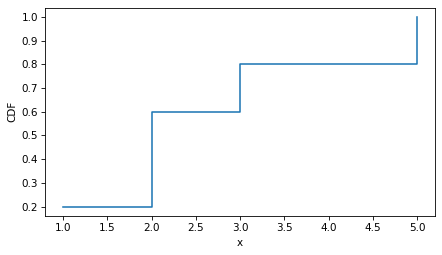

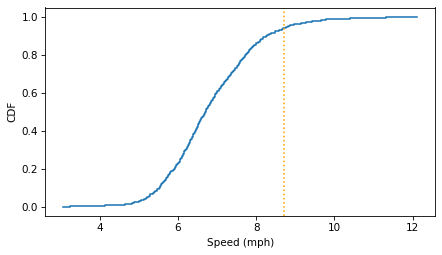

In [11]:
# Distributions

"""
Context: introduces CDFs from PMFs and raw data, later percentile and inverse operations depend on this
Plain-English: builds a CDF, reads cumulative probabilities, plots it, then applies it to real data
Real-world: used to answer questions like what fraction is below a value or what value corresponds to a percentile
Reappears: yes in percentile, ranking, and distribution comparisons
"""

from thinkstats import decorate
import matplotlib.pyplot as plt 
from empiricaldist import Pmf, Cdf 


t = [1, 2, 2, 3, 5]  # simple dataset

pmf = Pmf.from_seq(t)  
# build PMF from sequence

print(
    "PMF = ", pmf
     )  
# display probability mass function

print(
    "PMF at 2 = ", pmf[2]
     )  
# probability of value 2

cdf = pmf.make_cdf()  
# convert PMF to CDF
# make_cdf() method computes the cumulative sum of the probabilities in the Pmf.

print(
    "CDF = ", cdf
     )  
# display cumulative distribution

print(
    "CDF at 2 = ", cdf[2]
     )  
# probability that value <= 2

print(
    "CDF at 3 = ", cdf(3)
     )  
# cumulative probability at 3

print(
    "CDF at 4 = ", cdf(4)
     )  
# value not in data, still returns cumulative probability

plt.figure()  
# start a new figure so this plot does not overlap with later ones

cdf.step()    
# plot step function of CDF
# step() method plots the Cdf as a step function.

decorate(xlabel="x", ylabel="CDF")  # label axes

cdf_speeds = Cdf.from_seq(speeds)  
# build CDF from race speeds

plt.figure()  
# start a new figure so this plot does not overlap with later ones

cdf_speeds.step()  
# plot CDF of speeds

plt.axvline(my_speed, ls=":", color="orange")  
# Draw a vertical line to mark my speed on plot
# axvline → function inside matplotlib.pyplot
# axvline(...) → add a vertical line on the x-axis
# ls=":" Line style ; ":"= dotted line, "--" → dashed, "-" → solid

decorate(xlabel="Speed (mph)", ylabel="CDF")  # label axes

print(
    "Percentile from CDF = ", cdf_speeds(my_speed) * 100
     )  
# convert cumulative probability to percentile rank

print(
    "Median speed = ", cdf_speeds.inverse(0.5)
     )  
# find value at 50th percentile

# inverse() method in Cdf computes the inverse of the CDF for given a proportion between 0 and 1, it finds the corresponding value.
# the result of inverse cdf is called a quantile. So the inverse CDF is sometimes called the quantile function.

"""
Interpretation:
CDF accumulates probability up to a value, pmf gives exact probabilities while cdf gives cumulative ones
step plot shows increasing function, flat parts mean no values in that range
inverse finds value from probability, vertical line shows position of a specific observation
"""

print()

## Snippet 4- Comparing birth weight distributions with PMF and CDF
This snippet returns to NSFG data to compare birth weights for first babies and others. It first compares PMFs to see differences in probability at each value, then uses CDFs to compare the overall distribution more smoothly.

In [12]:
# Data Loading

"""
Context: compares birth weight distributions, later interpretation uses CDF differences
Plain-English: loads data, computes means, builds PMFs and CDFs, then plots comparisons
Real-world: used to compare distributions across groups like populations or categories
Reappears: yes in distribution comparison and visualization
"""

import matplotlib.pyplot as plt 
from thinkstats import decorate
from empiricaldist import Pmf  # PMF class
from thinkstats import two_bar_plots  # comparison plot
from os.path import basename, exists 

def download(url):
    filename = basename(url)

    print(f" Downloaded {filename} from URL") 
     
    if not exists(filename):
        from urllib.request import urlretrieve  

        local, _ = urlretrieve(url, filename)  

        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")  # download helper module
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")  # download dictionary
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")  # download data file

try:
    import statadict  
except ImportError:
    %pip install statadict


 Downloaded nsfg.py from URL
 Downloaded 2002FemPreg.dct from URL
 Downloaded 2002FemPreg.dat.gz from URL


c:\Users\DCL\Desktop\saadman vai\thinkstat\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


Mean first weights =  7.201094430437772
Mean other weights =  7.325855614973262



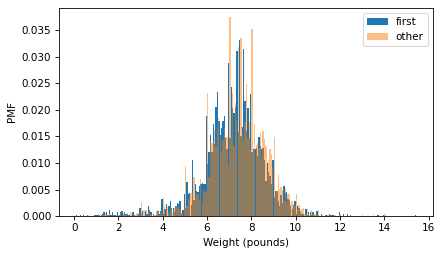

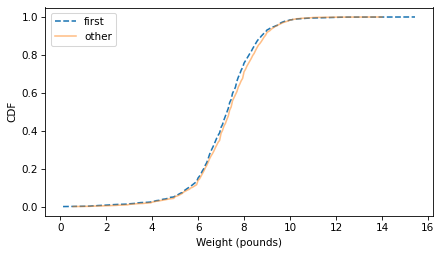

In [13]:
from nsfg import get_nsfg_groups  # import function to get grouped data

live, firsts, others = get_nsfg_groups()  # load pregnancy groups

first_weights = firsts["totalwgt_lb"].dropna()  
# extract and clean total birth weights in pounds for first baby
# using dropna to remove values that are nan.

print(
    "Mean first weights = ", first_weights.mean()
     )  
# average birth weights in pounds for first baby

other_weights = others["totalwgt_lb"].dropna()  
# extract and clean other baby weights

print(
    "Mean other weights = ", other_weights.mean()
     )  
# average birth weights in pounds for others

first_pmf = Pmf.from_seq(first_weights, name="first")  # PMF for first babies
other_pmf = Pmf.from_seq(other_weights, name="other")  # PMF for others


plt.figure()  
# start a new figure so this plot does not overlap with later ones

two_bar_plots(first_pmf, other_pmf, width=0.06)  
# compare PMFs by two bar plot

decorate(xlabel="Weight (pounds)", ylabel="PMF")  
# label axes

first_cdf = first_pmf.make_cdf()  # convert to CDF
other_cdf = other_pmf.make_cdf()  # convert to CDF

plt.figure()  
# start a new figure so this plot does not overlap with later ones

first_cdf.plot(ls="--")  
# plot first baby CDF

other_cdf.plot(alpha=0.5)  
# plot other baby CDF

decorate(xlabel="Weight (pounds)", ylabel="CDF")  # label axes

"""
Interpretation:
PMFs show probability differences at exact weights, CDFs show cumulative comparison
mean gives central tendency, shift between curves shows which group tends heavier
CDF separation indicates consistent difference across range
"""

print()

## Snippet 5- Cleaning birth weight data and its effect on statistics
This snippet shows how raw survey data can distort statistical results if not cleaned properly. It compares calculations using uncleaned and cleaned birth weight data to highlight how missing or invalid values affect counts, means, and standard deviations.

In [ ]:
# Data Cleaning

"""
Context: introduces data cleaning before computing statistics, later percentile analysis depends on clean data
Plain-English: loads raw birth weight data, cleans invalid values, then compares statistics before and after cleaning
Real-world: essential step in any data pipeline to avoid misleading results
Reappears: yes in all later statistical computations
"""

import numpy as np
from nsfg import read_stata  # function to read Stata dataset

dct_file = "2002FemPreg.dct"  # dictionary file
dat_file = "2002FemPreg.dat.gz"  # data file

preg = read_stata(dct_file, dat_file)  # load pregnancy dataset

birthwgt_lb = preg["birthwgt_lb"]  # weight in pounds
birthwgt_oz = preg["birthwgt_oz"]  # weight in ounces

print(
    preg["birthwgt_lb"].value_counts(dropna=False).sort_index()
     )

print(
    preg["birthwgt_oz"].value_counts(dropna=False).sort_index()
     )


from empiricaldist import Hist  # histogram class
# In previous versions, FreqTab was called Hist, 
# keep the name Hist for backward compatibility
# Hist = FreqTab


print(
    "Top ounce values =\n", Hist.from_seq(birthwgt_oz).tail(5)
     )  
# inspect unusual ounce values

print(
    "Top pound values =\n", Hist.from_seq(birthwgt_lb).tail(5)
     )  
# inspect unusual pound values

birthwgt_lb_clean = birthwgt_lb.replace([51, 97, 98, 99], np.nan)  
# clean invalid pound codes

birthwgt_oz_clean = birthwgt_oz.replace([97, 98, 99], np.nan)  
# clean invalid ounce codes
# preg["birthwgt_lb"] is pounds, 
# preg["birthwgt_oz"]/16 converts ounces to pounds

total_weight_clean = birthwgt_lb_clean + birthwgt_oz_clean / 16  
# compute clean total birth weight in pounds

total_weight_bogus = birthwgt_lb + birthwgt_oz / 16  
# compute without cleaning

count1 = total_weight_bogus.count()   # counts before cleaning
count2 = total_weight_clean.count()   # count after cleaning

print("count1=", count1)
print("count2=", count2)

diff = count1 - count2  
# number of invalid rows removed

print(
    "bogus count = ", diff
     )  
# how many invalid entries

print(
    "Removal percentage = ", diff / count2 * 100
     )  
# percentage removed
# how much (percentage) bogus values contains in the dataset 


mean1 = total_weight_bogus.mean() # means before
mean2 = total_weight_clean.mean()  # means after

print(
    "bogus Means = ", mean1
     )  

print(
    "clean Means = ", mean2
     )  

print(
    "Mean difference in % = ", (mean1 - mean2) / mean2 * 100
     )  
# relative change

std1, std2 = total_weight_bogus.std(), total_weight_clean.std()  # standard deviations

print(
    "bogus Std= ", std1
     ) 

print(
    "clean Std= ", std2
     )

print(
    "Std difference % = ", (std1 - std2) / std2 * 100
     )  
# relative change
# Std difference % tells about the uncleaned (bogus) data gives a spread that is ~50% different from the correct one

"""
Interpretation:
hist reveals invalid codes, cleaning replaces them with NaN so they are excluded
counts drop after cleaning, showing how many bad values existed
mean and std shift indicates raw data was biased, clean data gives more reliable statistics
"""

print()

birthwgt_lb
0.0        8
1.0       40
2.0       53
3.0       98
4.0      229
5.0      697
6.0     2223
7.0     3049
8.0     1889
9.0      623
10.0     132
11.0      26
12.0      10
13.0       3
14.0       3
15.0       1
51.0       1
97.0       1
98.0       1
99.0      57
NaN     4449
Name: count, dtype: int64
birthwgt_oz
0.0     1037
1.0      408
2.0      603
3.0      533
4.0      525
5.0      535
6.0      709
7.0      501
8.0      756
9.0      505
10.0     475
11.0     557
12.0     555
13.0     487
14.0     475
15.0     378
97.0       1
98.0       1
99.0      46
NaN     4506
Name: count, dtype: int64
Top ounce values =
 birthwgt_oz
14.0    475
15.0    378
97.0      1
98.0      1
99.0     46
Name: , dtype: int64
Top pound values =
 birthwgt_lb
15.0     1
51.0     1
97.0     1
98.0     1
99.0    57
Name: , dtype: int64
count1= 9087
count2= 9038
bogus count =  49
Removal percentage =  0.5421553441026776
bogus Means =  (np.float64(7.319680587652691),)
clean Means =  7.265628457623368
Mean

## Snippet 6- Skewness and percentile-based statistics
This snippet compares distribution shape using both moment-based and percentile-based measures. It computes skewness from raw values, then uses the CDF to calculate median, interquartile range, and quartile-based skewness to show more robust summaries.

In [ ]:
# Distributions

"""
Context: compares skewness and percentile statistics, later interpretation uses robust measures
Plain-English: computes skewness, compares clean vs raw, then uses CDF for median, IQR, and quartile skewness
Real-world: used when outliers or bad data affect traditional statistics
Reappears: yes in robust statistics and distribution summaries
"""

from empiricaldist import Cdf  # CDF class

def skewness(seq):
    # Compute the skewness of a sequence

    deviations = seq - seq.mean()  
    # compute deviations from mean

    return np.mean(deviations**3) / seq.std(ddof=0) ** 3  
    # skewness formula

skew1 = skewness(total_weight_bogus)  
# skewness before cleaning

skew2 = skewness(total_weight_clean)  
# skewness after cleaning

print(
    "Skewness (bogus, clean) = ", skew1, skew2
     )  
# compare skewness

print(
    "Relative skew error = ", (skew1 - skew2) / skew2
     )  
# how far bogus skew is from clean

cdf_total_weight_bogus = Cdf.from_seq(total_weight_bogus)  # CDF from raw data
cdf_total_weight_clean = Cdf.from_seq(total_weight_clean)  # CDF from cleaned data

# inverse method to compute the 50th percentile, which is the median
# inverse() method in "Cdf" computes the inverse of the CDF for given a proportion between 0 and 1, it finds the corresponding value.

def median(cdf):
    m = cdf.inverse(0.5)  # value at 50th percentile
    return m

print(
    "Median (bogus, clean) = ", median(cdf_total_weight_bogus), median(cdf_total_weight_clean)
     )  # compare medians

def iqr(cdf):
    Q1, Q3 = cdf.inverse([0.25, 0.75])  # 25th and 75th percentiles
    IQR = Q3 - Q1
    return IQR  # interquartile range

print(
    "IQR (bogus, clean) = ", iqr(cdf_total_weight_bogus), iqr(cdf_total_weight_clean)
     )  # compare spread

"""def quartile_skewness(cdf):
    Q1, median, Q3 = cdf.inverse([0.25, 0.5, 0.75])  # quartiles
    midpoint = (Q3 + Q1) / 2  # midpoint of quartiles
    semi_iqr = (Q3 - Q1) / 2  # quartile deviation
    return (midpoint - median) / semi_iqr  # quartile skewness
"""

def quartile_skewness(cdf):
    Q1, median, Q3 = cdf.inverse([0.25, 0.5, 0.75])  # quartiles
    iqr = Q3 - Q1
    return (Q3 + Q1 - 2*median) / iqr  # quartile skewness

qskew1 = quartile_skewness(cdf_total_weight_bogus)
qskew2 = quartile_skewness(cdf_total_weight_clean)

print(
    "Quartile skewness (bogus, clean) = ", qskew1, qskew2
     )  # compare quartile skewness

"""
Interpretation:
moment skewness is sensitive to bad data, clean vs bogus shows difference
median and IQR rely on percentiles so are more stable
quartile skewness compares shape using quartiles, less affected by extreme values
"""

print()

Skewness (bogus, clean) =  22.251846195422484 -0.5895062687577698
Relative skew error =  -38.74658112171127
Median (bogus, clean) =  7.375 7.375
IQR (bogus, clean) =  1.625 1.625
Quartile skewness (bogus, clean) =  -0.07692307692307693 -0.07692307692307693



## Snippet 7- Random sampling from a CDF
This snippet introduces random sampling from a distribution using a CDF. It generates synthetic data that follows the same distribution as the original speeds and shows how percentile ranks behave for a random sample.

sample= [6.66666667 6.25       3.27868852 ... 6.31578947 6.66666667 7.05882353]


'\nInterpretation:\ninverse CDF maps uniform random numbers to distribution values\nsample CDF should resemble original if sampling is correct\npercentile ranks of random samples form uniform distribution\nbuilt-in sample method simplifies same process\n'

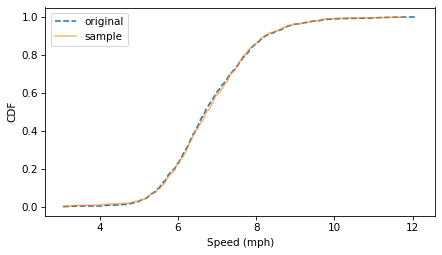

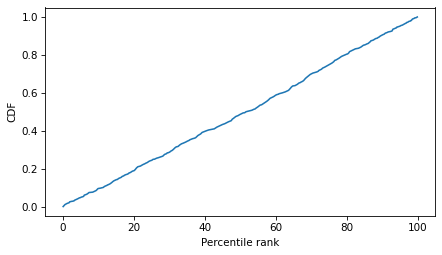

In [ ]:
# Simulation

"""
Context: introduces random sampling from distributions, later simulations rely on this idea
Plain-English: draws random samples using a CDF, compares sample to original, then analyzes percentile ranks
Real-world: used to simulate data when the true distribution is known
Reappears: yes in simulation and probabilistic modeling
"""
import matplotlib.pyplot as plt 

def sample_from_cdf(cdf, n):
    ps = np.random.random(size=n)  
    # generate uniform random probabilities between 0 and 1

    return cdf.inverse(ps)         
    # map probabilities to values using inverse CDF
    # return value x by matching each random p with cumulative probability

cdf_speeds = Cdf.from_seq(speeds)  
# build CDF from race speeds

sample = sample_from_cdf(cdf_speeds, 1001)  
# generate sample from speed distribution

print(
    "sample=", sample
     )

cdf_sample = Cdf.from_seq(sample)  
# build CDF from generated sample

cdf_speeds.plot(label="original", ls="--")  
# plot original distribution

cdf_sample.plot(label="sample", alpha=0.6)  
# plot sampled distribution

decorate(xlabel="Speed (mph)", ylabel="CDF")  # label axes


percentile_ranks = cdf_speeds(sample) * 100  
# compute percentile rank of each sampled value

cdf_percentile_rank = Cdf.from_seq(percentile_ranks)  
# build CDF of percentile ranks

plt.figure()  
# start a new figure so this plot does not overlap with later ones

cdf_percentile_rank.plot()  
# plot percentile rank distribution

decorate(xlabel="Percentile rank", ylabel="CDF")  # label axes


sample = cdf_speeds.sample(1001)  
# built-in method to sample directly from CDF

"""
Interpretation:
inverse CDF maps uniform random numbers to distribution values
sample CDF should resemble original if sampling is correct
percentile ranks of random samples form uniform distribution
built-in sample method simplifies same process
"""